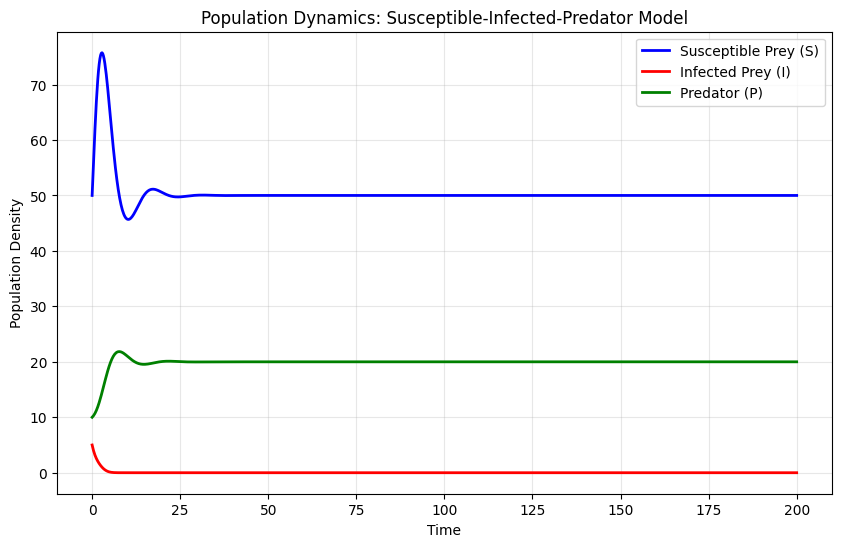

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def eco_epidemiological_model(t, y, r, K, beta, alpha1, alpha2, delta, mu, e, gamma):
    S, I, P = y
    dSdt = r * S * (1 - (S + I) / K) - beta * S * I - alpha1 * S * P
    didt = beta * S * I - (delta + mu) * I - alpha2 * I * P
    dPdt = P * (e * (alpha1 * S + alpha2 * I) - gamma)
    return [dSdt, didt, dPdt]

params = {
    'r': 1.2,        # Growth rate of prey
    'K': 150.0,      # Carrying capacity
    'beta': 0.01,    # Infection rate
    'alpha1': 0.04,  # Attack rate on susceptible prey
    'alpha2': 0.08,  # Attack rate on infected prey (higher = easier to catch)
    'delta': 0.2,    # Disease-induced mortality
    'mu': 0.1,       # Natural mortality of infected
    'e': 0.15,       # Conversion efficiency
    'gamma': 0.3     # Predator mortality rate
}

y0 = [50.0, 5.0, 10.0] 
t_span = (0, 200)
t_eval = np.linspace(0, 200, 1000)

sol = solve_ivp(
    eco_epidemiological_model, 
    t_span, 
    y0, 
    args=tuple(params.values()), 
    t_eval=t_eval
)

plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[0], label='Susceptible Prey (S)', color='blue', lw=2)
plt.plot(sol.t, sol.y[1], label='Infected Prey (I)', color='red', lw=2)
plt.plot(sol.t, sol.y[2], label='Predator (P)', color='green', lw=2)
plt.title('Population Dynamics: Susceptible-Infected-Predator Model')
plt.xlabel('Time')
plt.ylabel('Population Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()